In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import GridSearchCV

# Check Basic Information for Data Set

In [2]:
df=pd.read_csv('predictive_maintenance.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [3]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB


In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

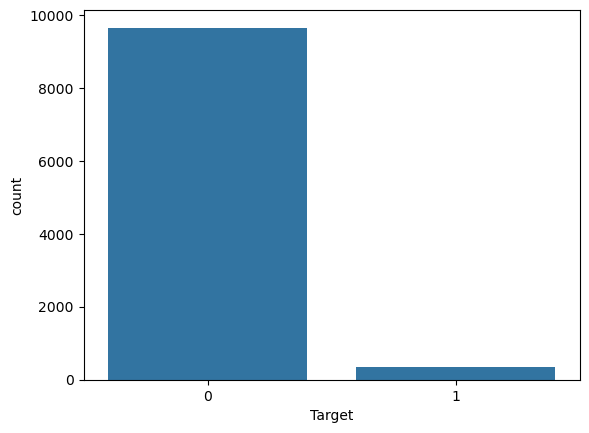

In [7]:
sns.countplot(x='Target',data=df)
plt.show()

# Above Plot Indicates Class Imbalance Problem so wil handle it using Statify during Data Split and later SMOT method

In [8]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target'],
      dtype='object')

In [9]:
df.drop(['UDI','Product ID'],axis=1,inplace=True)
le=LabelEncoder()
df['Type']=le.fit_transform(df['Type'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


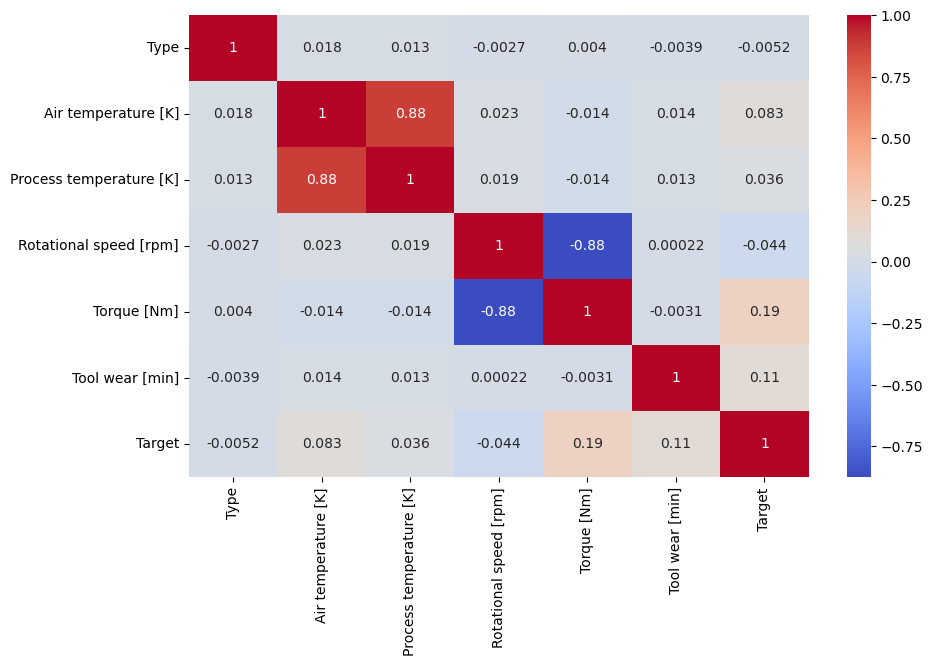

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

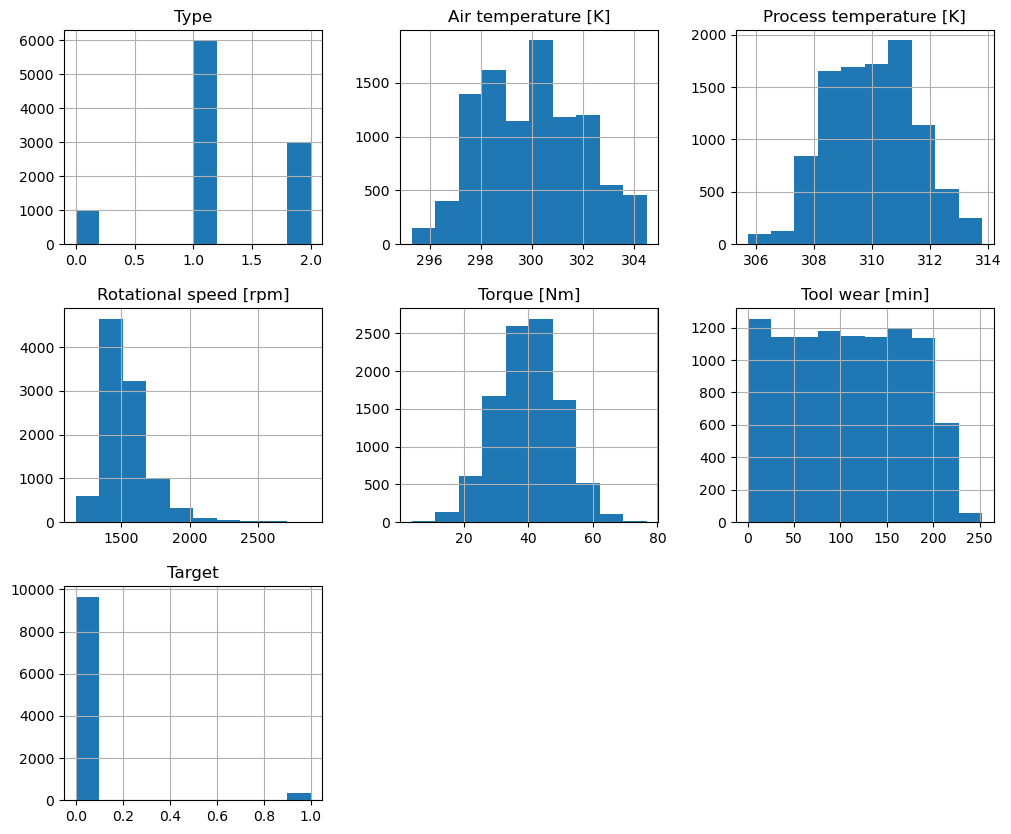

In [11]:
df.hist(figsize=(12,10))
plt.show()

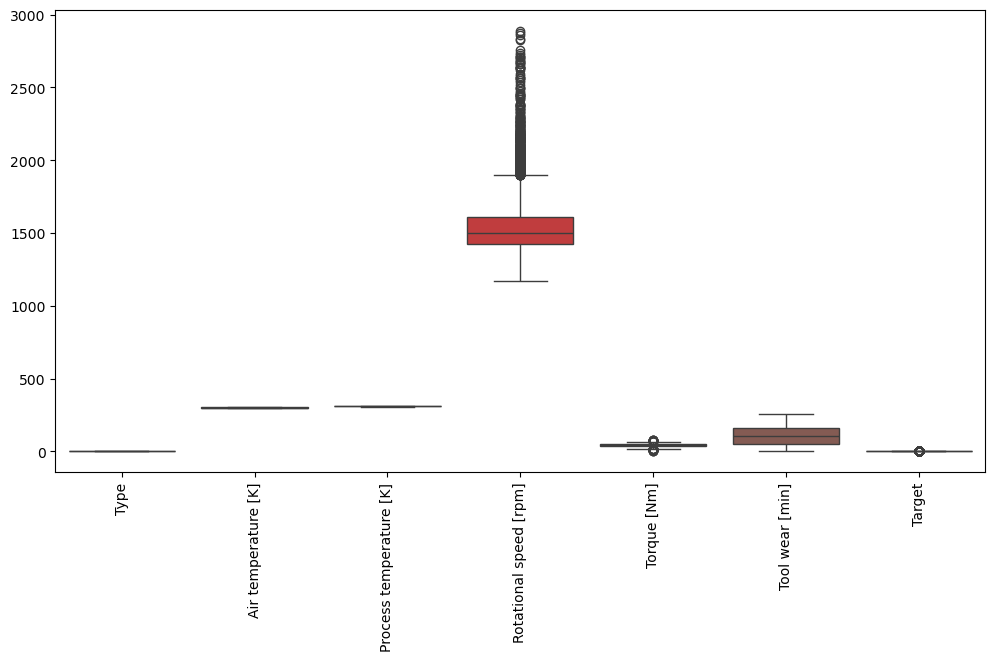

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Train Test Split

In [13]:
X=df.drop('Target',axis=1)
y=df['Target']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [14]:
skewness = X.skew()
print("Skewness:\n", skewness)

Skewness:
 Type                      -0.111126
Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64


# Use SMOT for Class Imbalance

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before:", y_train.shape)
print("After:", y_resampled.shape)

Before: (8000,)
After: (15458,)


#  Create a function to avoid duplicate code each time we want to train a model

In [16]:
# Create a function to avoid duplicate code each time we want to train a model
def train_and_evaluate_model(model, x_train, y_train, x_test, y_test):
    
    # Train
    model.fit(x_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # ================= TRAIN METRICS =================
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, average='weighted')
    train_rec = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    train_cm = confusion_matrix(y_train, y_train_pred)

    # ================= TEST METRICS =================
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average='weighted')
    test_rec = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    test_cm = confusion_matrix(y_test, y_test_pred)

    # ================= PRINT =================
    print(f"\nModel: {model.__class__.__name__}")
    
    print("\nTraining Results:")
    print(f"Accuracy: {train_acc:.4f}")
    print(f"Precision: {train_prec:.4f}")
    print(f"Recall: {train_rec:.4f}")
    print(f"F1 Score: {train_f1:.4f}")
    print("Confusion Matrix:\n", train_cm)
    
    print("\nTesting Results:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall: {test_rec:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print("Confusion Matrix:\n", test_cm)

    # ================= RETURN =================
    return {
        'Model': model.__class__.__name__,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train Precision': train_prec, 
        'Test Precision': test_prec,
        'Train Recall': train_rec,
        'Test Recall': test_rec,
        'Train F1': train_f1,
        'Test F1': test_f1,
        'Train Confusion Matrix': train_cm,
        'Test Confusion Matrix': test_cm
    }

In [17]:
models = [
    LogisticRegression(max_iter=2000),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    KNeighborsClassifier(),
    SVC(),
    GaussianNB(),
    GradientBoostingClassifier()
]

for model in models:
    train_and_evaluate_model(model, X_resampled, y_resampled, X_test, y_test)


Model: LogisticRegression

Training Results:
Accuracy: 0.8205
Precision: 0.8206
Recall: 0.8205
F1 Score: 0.8205
Confusion Matrix:
 [[6365 1364]
 [1410 6319]]

Testing Results:
Accuracy: 0.8230
Precision: 0.9642
Recall: 0.8230
F1 Score: 0.8775
Confusion Matrix:
 [[1589  343]
 [  11   57]]

Model: DecisionTreeClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[7729    0]
 [   0 7729]]

Testing Results:
Accuracy: 0.9560
Precision: 0.9693
Recall: 0.9560
F1 Score: 0.9613
Confusion Matrix:
 [[1865   67]
 [  21   47]]

Model: RandomForestClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[7729    0]
 [   0 7729]]

Testing Results:
Accuracy: 0.9710
Precision: 0.9776
Recall: 0.9710
F1 Score: 0.9735
Confusion Matrix:
 [[1888   44]
 [  14   54]]

Model: KNeighborsClassifier

Training Results:
Accuracy: 0.9764
Precision: 0.9773
Recall: 0.9764
F1 Score: 0.9764
Confusi

# For SVC, Random Forest and Gradient boost using Grid search CV

In [18]:
svm = SVC()

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

svm_grid.fit(X_resampled, y_resampled)

print("SVM Best Params:", svm_grid.best_params_)

# Evaluate using your function
train_and_evaluate_model(
    svm_grid.best_estimator_,
    X_resampled, y_resampled,
    X_test, y_test
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVM Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Model: SVC

Training Results:
Accuracy: 0.9716
Precision: 0.9722
Recall: 0.9716
F1 Score: 0.9716
Confusion Matrix:
 [[7376  353]
 [  86 7643]]

Testing Results:
Accuracy: 0.9435
Precision: 0.9713
Recall: 0.9435
F1 Score: 0.9539
Confusion Matrix:
 [[1832  100]
 [  13   55]]


{'Model': 'SVC',
 'Train Accuracy': 0.9716004657782378,
 'Test Accuracy': 0.9435,
 'Train Precision': 0.9721639330788416,
 'Test Precision': 0.9712580120639918,
 'Train Recall': 0.9716004657782378,
 'Test Recall': 0.9435,
 'Train F1': 0.971591990446188,
 'Test F1': 0.9538705855953725,
 'Train Confusion Matrix': array([[7376,  353],
        [  86, 7643]]),
 'Test Confusion Matrix': array([[1832,  100],
        [  13,   55]])}

In [19]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_resampled, y_resampled)

print("RF Best Params:", rf_grid.best_params_)

train_and_evaluate_model(
    rf_grid.best_estimator_,
    X_resampled, y_resampled,
    X_test, y_test
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
RF Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Model: RandomForestClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[7729    0]
 [   0 7729]]

Testing Results:
Accuracy: 0.9700
Precision: 0.9768
Recall: 0.9700
F1 Score: 0.9726
Confusion Matrix:
 [[1887   45]
 [  15   53]]


{'Model': 'RandomForestClassifier',
 'Train Accuracy': 1.0,
 'Test Accuracy': 0.97,
 'Train Precision': 1.0,
 'Test Precision': 0.9767694585720724,
 'Train Recall': 1.0,
 'Test Recall': 0.97,
 'Train F1': 1.0,
 'Test F1': 0.9725934724814751,
 'Train Confusion Matrix': array([[7729,    0],
        [   0, 7729]]),
 'Test Confusion Matrix': array([[1887,   45],
        [  15,   53]])}

In [20]:
gb = GradientBoostingClassifier()

gb_params = {
   'n_estimators': [100, 200],    
    'learning_rate': [0.05, 0.1],
'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5, 
   scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

gb_grid.fit(X_resampled, y_resampled)

print("GB Best Params:", gb_grid.best_params_)
best_gb = gb_grid.best_estimator_
train_and_evaluate_model(
    best_gb,
    X_resampled, y_resampled,
    X_test, y_test
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GB Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Model: GradientBoostingClassifier

Training Results:
Accuracy: 0.9975
Precision: 0.9975
Recall: 0.9975
F1 Score: 0.9975
Confusion Matrix:
 [[7712   17]
 [  22 7707]]

Testing Results:
Accuracy: 0.9730
Precision: 0.9793
Recall: 0.9730
F1 Score: 0.9753
Confusion Matrix:
 [[1890   42]
 [  12   56]]


{'Model': 'GradientBoostingClassifier',
 'Train Accuracy': 0.9974770345452193,
 'Test Accuracy': 0.973,
 'Train Precision': 0.997477242738454,
 'Test Precision': 0.9793339342045967,
 'Train Recall': 0.9974770345452193,
 'Test Recall': 0.973,
 'Train F1': 0.9974770342812553,
 'Test F1': 0.9753341252333276,
 'Train Confusion Matrix': array([[7712,   17],
        [  22, 7707]]),
 'Test Confusion Matrix': array([[1890,   42],
        [  12,   56]])}

In [21]:
tuned_results = []

tuned_results.append(
    train_and_evaluate_model(
        svm_grid.best_estimator_,
        X_resampled, y_resampled,
        X_test, y_test
    )
)

tuned_results.append(
    train_and_evaluate_model(
        rf_grid.best_estimator_,
        X_resampled, y_resampled,
        X_test, y_test
    )
)

tuned_results.append(
    train_and_evaluate_model(
        gb_grid.best_estimator_,
        X_resampled, y_resampled,
        X_test, y_test
    )
)

import pandas as pd


Model: SVC

Training Results:
Accuracy: 0.9716
Precision: 0.9722
Recall: 0.9716
F1 Score: 0.9716
Confusion Matrix:
 [[7376  353]
 [  86 7643]]

Testing Results:
Accuracy: 0.9435
Precision: 0.9713
Recall: 0.9435
F1 Score: 0.9539
Confusion Matrix:
 [[1832  100]
 [  13   55]]

Model: RandomForestClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[7729    0]
 [   0 7729]]

Testing Results:
Accuracy: 0.9700
Precision: 0.9768
Recall: 0.9700
F1 Score: 0.9726
Confusion Matrix:
 [[1887   45]
 [  15   53]]

Model: GradientBoostingClassifier

Training Results:
Accuracy: 0.9979
Precision: 0.9979
Recall: 0.9979
F1 Score: 0.9979
Confusion Matrix:
 [[7716   13]
 [  19 7710]]

Testing Results:
Accuracy: 0.9730
Precision: 0.9789
Recall: 0.9730
F1 Score: 0.9752
Confusion Matrix:
 [[1891   41]
 [  13   55]]


# Finally going with the Gradient Boosting Classifier as this model achieved the highest testing accuracy of 97.30%, 
# outperforming both Support Vector Classifier (SVC) and Random Forest. It also recorded the highest F1-score (97.52%), 
# indicating an excellent balance between precision and recall.

## Although the Random Forest model achieved 100% training accuracy, this is a strong indication that it may have overfit the training data. 

## In contrast, the Gradient Boosting Classifier achieved:

### Training Accuracy: 99.79%
### Testing Accuracy: 97.30%

## The small gap between training and testing accuracy suggests that the model generalizes well to new data and is less likely to overfit.

In [23]:
import joblib

Final_model = best_gb
Final_model.fit(X_resampled, y_resampled)

joblib.dump(Final_model, 'PredictiveMaintenance.pkl')
scaler_filename = 'PredictiveMaintenanceScaler.pkl'
joblib.dump(le, "label_encoder.pkl")
joblib.dump(scaler, scaler_filename)

['PredictiveMaintenanceScaler.pkl']